Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


Load Dataset

In [8]:
import pandas as pd

df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Understanding

In this section we explore the dataset structure, data types, missing values, and duplicate records before performing analysis.

Dataset Shape

In [9]:
df.shape

(9994, 21)

Column Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Summary Statistics

In [11]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Missing Values Check

In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicate Records Check

In [13]:
df.duplicated().sum()

np.int64(0)

##Data Preparation & Feature Engineering

Convert Dates

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Create Year Column

In [15]:
df['Year'] = df['Order Date'].dt.year

Create Month Column

In [16]:
df['Month'] = df['Order Date'].dt.month_name()

Create Quarter Column

In [17]:
df['Quarter'] = df['Order Date'].dt.quarter

Create Shipping Days

In [18]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

Verify New Columns

In [19]:
df[['Order Date',
    'Ship Date',
    'Year',
    'Month',
    'Quarter',
    'Shipping Days']].head()

,Order Date,Ship Date,Year,Month,Quarter,Shipping Days
0,2016-11-08,2016-11-11,2016,November,4,3
1,2016-11-08,2016-11-11,2016,November,4,3
2,2016-06-12,2016-06-16,2016,June,2,4
3,2015-10-11,2015-10-18,2015,October,4,7
4,2015-10-11,2015-10-18,2015,October,4,7


##Business KPIs


## Key Performance Indicators (KPIs)

Total Sales

In [20]:
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


Total Profit

In [21]:
total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


Total Orders

In [22]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


Total Customers

In [23]:
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


Average Shipping Time

In [24]:
avg_shipping = df['Shipping Days'].mean()
print(f"Average Shipping Days: {avg_shipping:.2f}")

Average Shipping Days: 3.96


##Sales Analysis
Analyzing sales performance across time, categories, regions, and customer segments.

Sales Trend by Year

In [25]:
sales_by_year = df.groupby('Year')['Sales'].sum()

sales_by_year

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


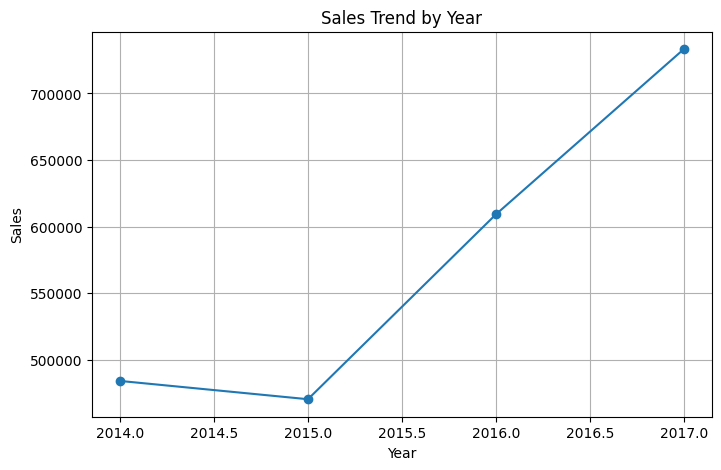

In [27]:
import matplotlib.pyplot as plt

sales_by_year.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title('Sales Trend by Year')
plt.ylabel('Sales')
plt.grid(True)

plt.show()

Sales by Category

In [28]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category.sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


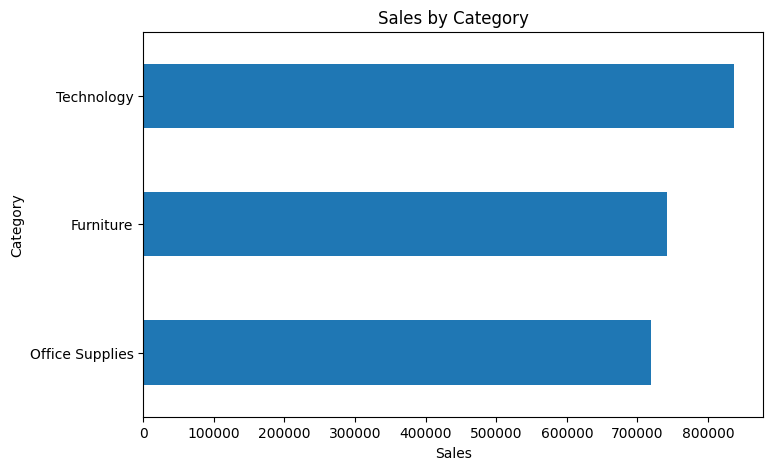

In [29]:
sales_by_category.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Sales by Category')
plt.xlabel('Sales')

plt.show()

Profit by Category

In [30]:
profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category.sort_values()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


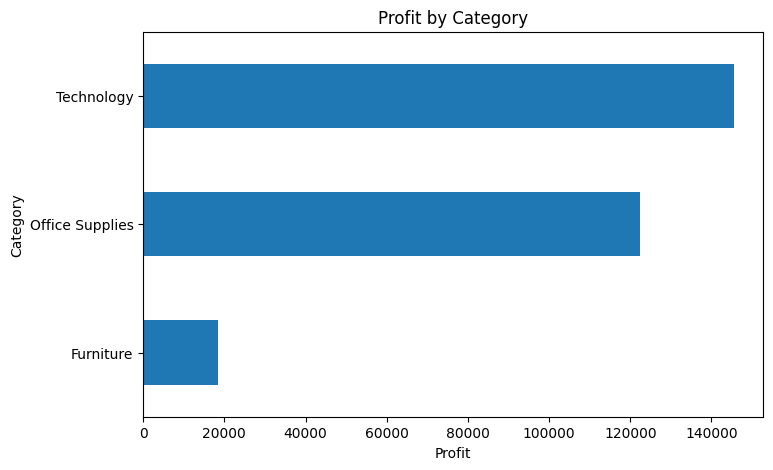

In [31]:
profit_by_category.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Profit by Category')
plt.xlabel('Profit')

plt.show()

Top 10 Products by Sales

In [32]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


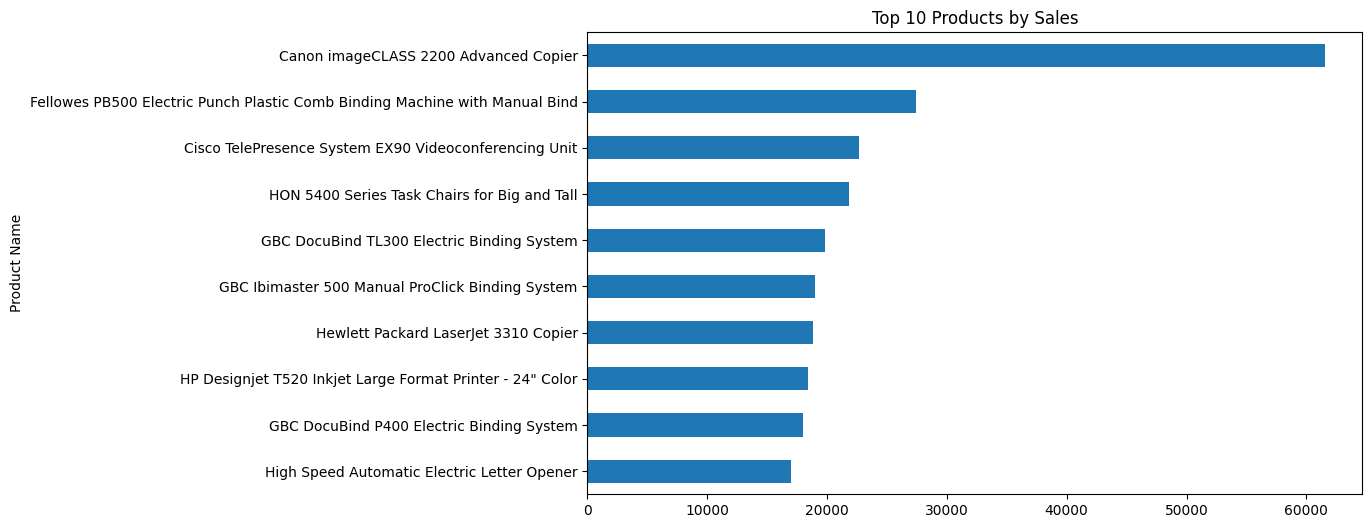

In [33]:
top_products.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Products by Sales')

plt.show()

Regional Sales

In [34]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


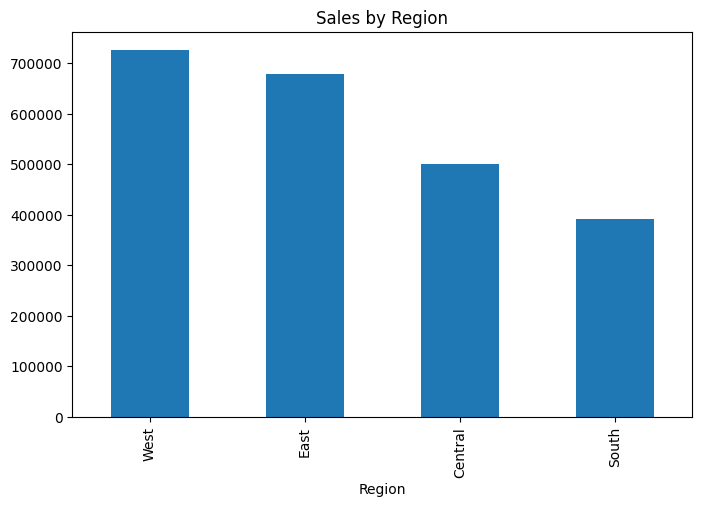

In [35]:
region_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Region')

plt.show()

# Customer Analysis
Analyzing customer segments and purchasing behavior.

Customer Segment Sales

In [36]:
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


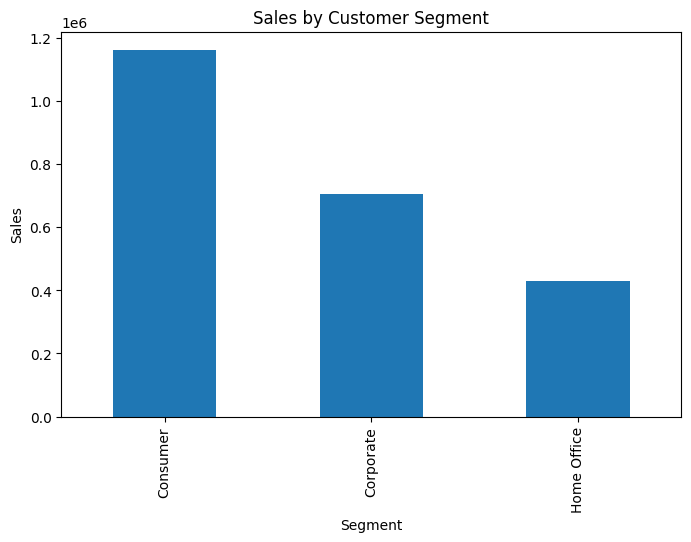

In [37]:
segment_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Customer Segment')
plt.ylabel('Sales')

plt.show()

Customer Segment Profit

In [38]:
segment_profit = (
    df.groupby('Segment')['Profit']
    .sum()
    .sort_values(ascending=False)
)

segment_profit

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


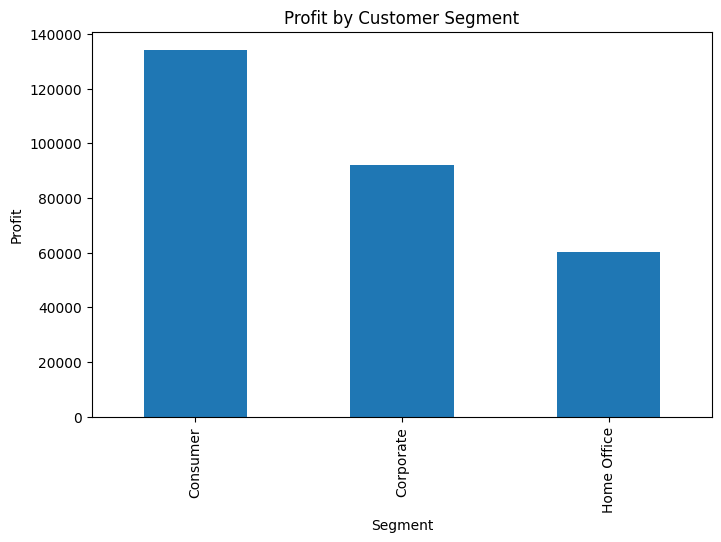

In [39]:
segment_profit.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit by Customer Segment')
plt.ylabel('Profit')

plt.show()

Top 10 Customers

In [40]:
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


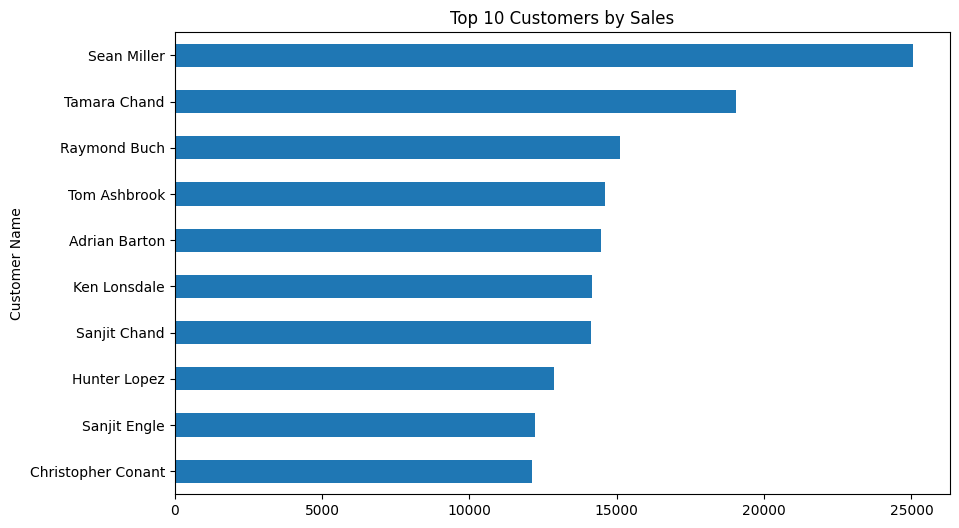

In [41]:
top_customers.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Customers by Sales')

plt.show()

Profit Distribution

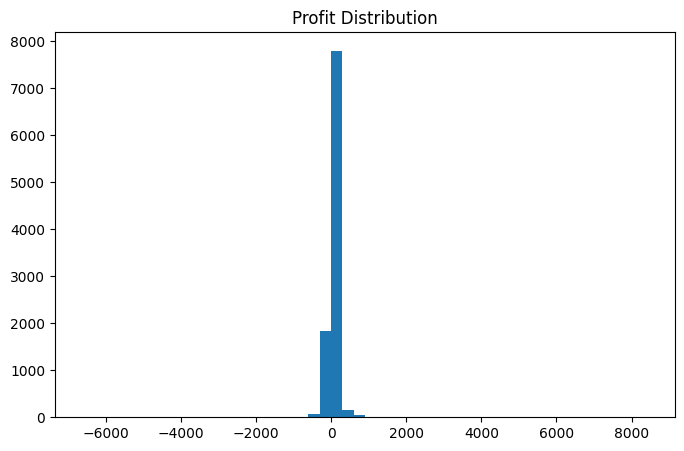

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Profit'], bins=50)

plt.title('Profit Distribution')

plt.show()

# Advanced Data Visualizations
Visualizing sales and profit trends across business dimensions.

Monthly Sales Trend

In [43]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

monthly_sales

,Sales
Month,
April,137762.1286
August,159044.0630
December,325293.5035
February,59751.2514
January,94924.8356
July,147238.0970
June,152718.6793
March,205005.4888
May,155028.8117


In [44]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales

,Sales
Month,
January,94924.8356
February,59751.2514
March,205005.4888
April,137762.1286
May,155028.8117
June,152718.6793
July,147238.0970
August,159044.0630
September,307649.9457


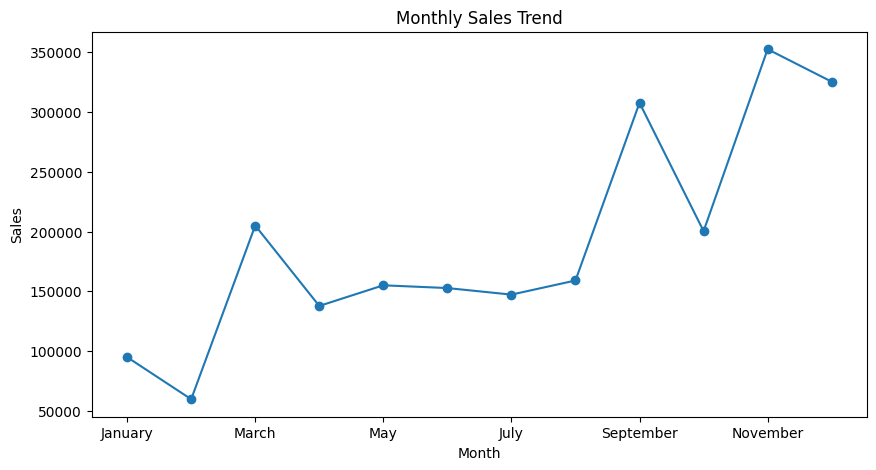

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.ylabel('Sales')

plt.show()

Profit by Region

In [46]:
profit_region = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_region

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


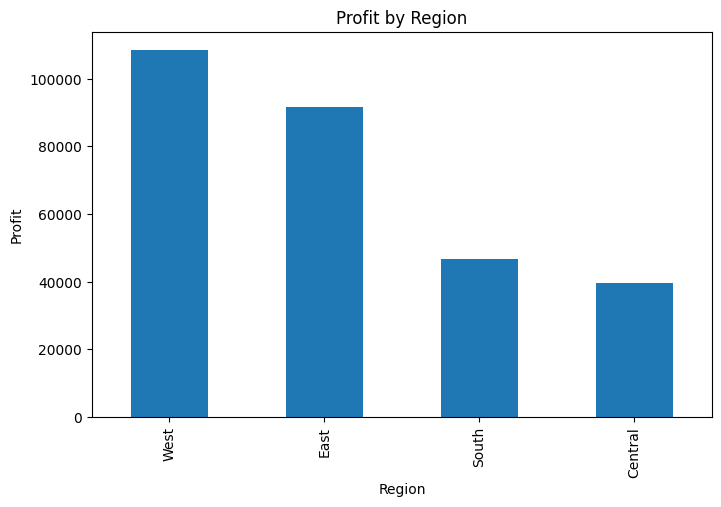

In [47]:
profit_region.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit by Region')
plt.ylabel('Profit')

plt.show()

Top 10 Sub-Categories

In [48]:
sub_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sub_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


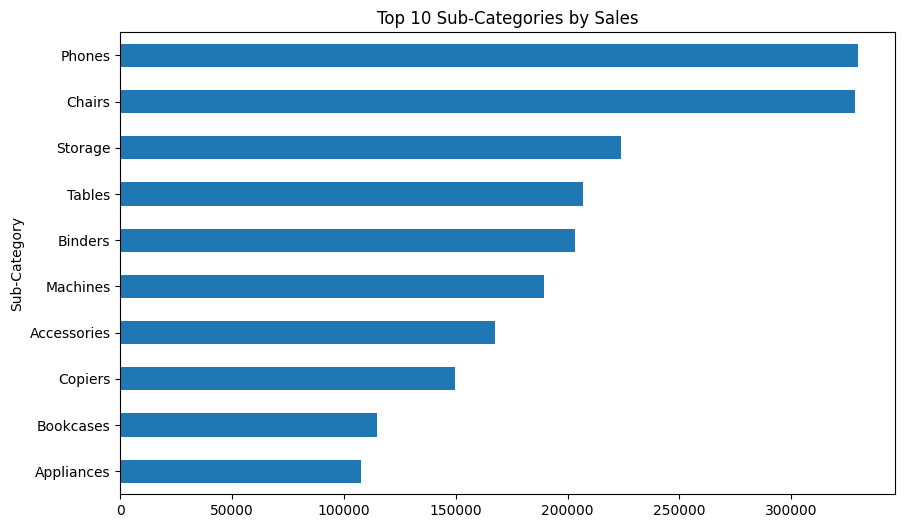

In [49]:
sub_sales.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Sub-Categories by Sales')

plt.show()

Correlation Heatmap

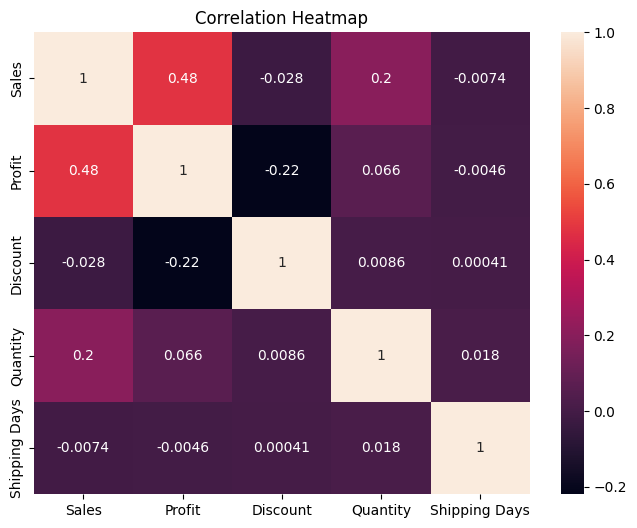

In [50]:
import seaborn as sns

corr = df[['Sales','Profit','Discount','Quantity','Shipping Days']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

# Executive Summary

## Key Findings

- **Total Sales:** $2.29 Million
- **Total Profit:**
- **Total Orders:** 5,009
- **Total Customers:** 793

## Main Insights

- Technology generated the highest sales revenue and overall profit among all product categories.
- Consumer customers contributed the largest share of both sales and profitability.
- The West region achieved the highest profit, making it the strongest-performing region.
- Sales peaked during November and December, indicating strong demand during the fourth quarter.
- Phones and Chairs were the top-performing product sub-categories based on total sales.
- Higher discount rates showed a negative impact on profitability, reducing overall profit margins.
- Most orders generated small profits, while a limited number of transactions produced exceptionally high profits.

## Business Recommendations

- Focus marketing campaigns on high-value Consumer customers to maximize revenue growth.
- Expand the Technology product portfolio, as it is the most profitable category.
- Increase inventory levels before the Q4 sales season to meet peak demand.
- Review discount strategies and avoid excessive discounting that negatively affects profitability.
- Implement targeted sales and marketing initiatives in the Central and South regions to improve performance.
- Strengthen customer retention programs for top-spending customers through loyalty rewards and personalized offers.

## Conclusion

This analysis identified key sales trends, customer behaviors, regional performance patterns, and profitability drivers within the business. Technology products, Consumer customers, and the West region were the primary contributors to business success. By optimizing inventory planning, improving regional performance, and maintaining profitable pricing strategies, the company can further increase revenue and profitability while supporting long-term growth.

In [ ]:
df.columns.tolist()